## Experiment 1: Data Quality Check And Cleaning


In [1]:
# Import required libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from io import StringIO
import warnings
from scipy.optimize import curve_fit

In [2]:
# Nature-style plotting configuration
import sys
from pathlib import Path
for _shared_path in (Path('shared'), Path('notebooks/shared')):
    if _shared_path.exists():
        sys.path.insert(0, str(_shared_path))

import matplotlib.pyplot as plt
import seaborn as sns
from plot_config import (
    set_nature_style, COLORS, TRANSITION_ORDER, TRANSITION_PALETTE,
    DURATION_ORDER, get_transition_palette, despine
)
set_nature_style()

#### Set up the data path

In [3]:
#  Set data paths
data_folder = os.path.join('..', 'rawdata')                    # Raw CSV folder
%config InlineBackend.figure_format = 'retina'  

#### Extract Prolific IDs (for online experiments)

In [4]:
# Function 0: extract prolific IDs
def extract_all_prolific_pids(data_folder):
    pid_dict = {}
    for file_path in glob.glob(os.path.join(data_folder, '*.csv')):
        sub_id = os.path.basename(file_path).split('_')[0]
        try:
            df = pd.read_csv(file_path)
            if 'PROLIFIC_PID' in df.columns:
                pid = df['PROLIFIC_PID'].iloc[0]
                pid_dict[sub_id] = pid
            else:
                pid_dict[sub_id] = 'NOT FOUND'
        except Exception as e:
            pid_dict[sub_id] = f'ERROR: {e}'
    return pid_dict
    Usage
    prolific_ids = extract_all_prolific_pids("path/to/data/folder")
    prolific_ids = extract_all_prolific_pids("path/to/data/folder")
    df_summary['PROLIFIC_PID'] = df_summary['subID'].map(prolific_ids)

#### Then we load the dataset with function 1, which will show all the collected participants

#### Load and clean raw data
Remove first 33 rows (30 practice trials + 3 screen setup rows).

In [5]:
import os
import glob
import pandas as pd
from io import StringIO

def basic_cleaning(data_folder):
    all_dfs = []
    files = glob.glob(os.path.join(data_folder, '*.csv'))
    print(f" Found {len(files)} CSV files in {data_folder}")
    encodings_to_try = ['utf-8', 'utf-8-sig', 'latin1', 'gbk', 'windows-1252']
    for file_path in files:
        lines = None
        for enc in encodings_to_try:
            try:
                with open(file_path, 'r', encoding=enc) as f:
                    lines = f.readlines()
                break  
            except UnicodeDecodeError:
                continue
        if lines is None:
            continue
        if len(lines) < 4:
            print(f" File too short: {file_path}")
            continue
        cleaned_lines = [lines[0]] + lines[33:]
        try:
            df = pd.read_csv(StringIO(''.join(cleaned_lines)))
        except Exception as e:
            continue
        if 'keyDuration' not in df.columns or 'TimeDur' not in df.columns:
            continue
        try:
            df['keyDuration'] = df['keyDuration'] / 1000.0
            df['ReproductionError'] = df['keyDuration'] - df['TimeDur']
            sub_id = os.path.basename(file_path).split('_')[0]
            df['subID'] = sub_id
            all_dfs.append(df)
        except Exception as e:
            continue
    if not all_dfs:
        return pd.DataFrame()
    print(f" Successfully processed {len(all_dfs)} files")
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

In [6]:
df_all = basic_cleaning(data_folder)


 Found 48 CSV files in ../rawdata
 File too short: ../rawdata/565665_SDMT1_2025-05-21_04h23.18.862.csv
 File too short: ../rawdata/302359_SDMT1_2025-05-21_07h01.32.828.csv
 File too short: ../rawdata/633634_SDMT1_2025-05-21_03h57.27.721.csv
 File too short: ../rawdata/513430_SDMT1_2025-05-21_15h03.49.007.csv
 File too short: ../rawdata/374811_Serial_Dependence_U_2025-05-21_05h11.52.215.csv
 Successfully processed 43 files


/var/folders/3r/hd70pw796ggfnfk6lnh1drlw0000gn/T/ipykernel_51632/1464676932.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(all_dfs, ignore_index=True)


#### Calculate trial retention ratio per subject

In [7]:
def calculate_trial_ratio(df, full_trial_count=240, use_outlier_column=True):
    """
     trial ：
        -  is_outlier 
        -  trial 、 trial 
    ：
        df (pd.DataFrame):  'subID'  'is_outlier'  dataframe
        full_trial_count (int or dict):  trial （， subID:count ）
        use_outlier_column (bool):  'is_outlier' 
    ：
        pd.DataFrame:  trial 
    """
    df = df.copy()
    if use_outlier_column and 'is_outlier' in df.columns:
        df_valid = df[df['is_outlier'] == False]
    else:
        df_valid = df
    total_trials = df.groupby('subID').size().rename('total_trials')
    valid_trials = df_valid.groupby('subID').size().rename('valid_trials')
    summary = pd.concat([total_trials, valid_trials], axis=1).fillna(0)
    summary['valid_trials'] = summary['valid_trials'].astype(int)
    if isinstance(full_trial_count, dict):
        summary['full_expected'] = summary.index.map(full_trial_count).fillna(240)
    else:
        summary['full_expected'] = full_trial_count
    summary['valid_ratio'] = summary['valid_trials'] / summary['full_expected']
    return summary.reset_index()


#### Outlier removal function
Remove outliers per `TimeDur` using IQR filtering + absolute error threshold.

In [8]:
def clean_extremes_grouped_by_duration(
    df_all,
    error_thresh=0.6,
    time_bounds=(0.8, 1.6),
    verbose=True
):
    """
    ： TimeDur  IQR ， is_outlier 。
    ：
        df_all (pd.DataFrame):  'TimeDur', 'keyDuration', 'ReproductionError'  DataFrame
        error_thresh (float): 
        time_bounds (tuple):  TimeDur 
        verbose (bool):  trial 
    ：
        pd.DataFrame:  'is_outlier'  DataFrame
    """
    df_all = df_all.copy().assign(is_outlier=False)
    for dur, df_group in df_all.groupby("TimeDur"):
        if not (time_bounds[0] <= dur <= time_bounds[1]):
            df_all.loc[df_group.index, "is_outlier"] = True
            continue
        if df_group["keyDuration"].isna().all() or df_group["ReproductionError"].isna().all():
            continue
        q1 = df_group["keyDuration"].quantile(0.25)
        q3 = df_group["keyDuration"].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask_iqr = (df_group["keyDuration"] < lower) | (df_group["keyDuration"] > upper)
        mask_err = df_group["ReproductionError"].abs() > error_thresh
        final_mask = mask_iqr | mask_err
        df_all.loc[df_group[final_mask].index, "is_outlier"] = True
    if verbose:
        n_outliers = df_all["is_outlier"].sum()
    return df_all


#### Outlier Removal Strategy
For each `TimeDur`, trials were excluded if: (1) `keyDuration` outside IQR ± 1.5×IQR, or (2) |ReproductionError| > 0.6s. Trials with `TimeDur` outside [0.8, 1.6]s were also discarded.

In [9]:
# Apply outlier removal
df2 = clean_extremes_grouped_by_duration(df_all, error_thresh=0.6)
print(f"Outliers marked: {df2['is_outlier'].sum()} / {len(df2)}")

# Calculate trial ratios
df_summary = calculate_trial_ratio(df2)
df_summary = df_summary.sort_values(by='valid_ratio', ascending=False).reset_index(drop=True)
print("\nSubject-wise trial ratios (sorted):")
for i, row in df_summary.iterrows():
    print(f"Subject {i+1}: {row['subID']}, valid_ratio = {row['valid_ratio']:.3f}")
df = df2

Outliers marked: 3750 / 10051

Subject-wise trial ratios (sorted):
Subject 1: 815266, valid_ratio = 0.992
Subject 2: 611856, valid_ratio = 0.992
Subject 3: 082622, valid_ratio = 0.983
Subject 4: 169207, valid_ratio = 0.971
Subject 5: 551900, valid_ratio = 0.967
Subject 6: 203316, valid_ratio = 0.958
Subject 7: 002046, valid_ratio = 0.954
Subject 8: 062573, valid_ratio = 0.954
Subject 9: 189058, valid_ratio = 0.942
Subject 10: 742322, valid_ratio = 0.929
Subject 11: 298043, valid_ratio = 0.925
Subject 12: 183923, valid_ratio = 0.921
Subject 13: 555268, valid_ratio = 0.896
Subject 14: 118354, valid_ratio = 0.892
Subject 15: 184189, valid_ratio = 0.887
Subject 16: 885939, valid_ratio = 0.883
Subject 17: 469417, valid_ratio = 0.871
Subject 18: 898122, valid_ratio = 0.854
Subject 19: 194491, valid_ratio = 0.850
Subject 20: 624708, valid_ratio = 0.829
Subject 21: 753780, valid_ratio = 0.821
Subject 22: 372056, valid_ratio = 0.804
Subject 23: 946439, valid_ratio = 0.792
Subject 24: 134707, va

#### Construct trial-level variables
Rename columns, compute n-back variables, and define `TransitionType` (HH, HL, LH, LL) based on coherence transitions.

In [10]:
def construct_trial_variables(df, max_n_back=10, verbose=True): 
    df = df.copy()
    # rename columns
    df = df.rename(columns={
        'trials.thisN': 'trial_num',
        'TimeDur': 'curDur',
        'keyDuration': 'rpr',
        'ReproductionError': 'curBias',
        'Coherence1': 'curCoherence'
    })
    # shift to get 1-back
    df['preDur1back'] = df.groupby('subID')['curDur'].shift(1)
    df['preCoherence1back'] = df.groupby('subID')['curCoherence'].shift(1)
    # overwrite with NaN where thisTrialN == 0
    df.loc[df['trials.thisTrialN'] == 0, ['preDur1back', 'preCoherence1back']] = np.nan
    # compute TransitionType
    def classify_transition(row):
        if pd.isnull(row['preCoherence1back']):
            return np.nan
        prev = 'Low' if row['preCoherence1back'] == 0.7 else 'High'
        curr = 'Low' if row['curCoherence'] == 0.7 else 'High'
        return prev[0] + curr[0]
    df['TransitionType'] = df.apply(classify_transition, axis=1)
    # add n-back variables (from 2-back to max_n_back)
    for n in range(2, max_n_back + 1):
        df[f'preDur{n}back'] = df.groupby('subID')['curDur'].shift(n)
        df[f'preCoherence{n}back'] = df.groupby('subID')['curCoherence'].shift(n)
    df = df.dropna(subset=['preDur1back', 'preCoherence1back']).copy()
    keep_cols = ['subID', 'trial_num', 'curDur', 'rpr', 'curBias', 'curCoherence',
                 'preDur1back', 'preCoherence1back', 'TransitionType', 'is_outlier'] + \
                [f'preDur{n}back' for n in range(2, max_n_back + 1)] + \
                [f'preCoherence{n}back' for n in range(2, max_n_back + 1)]
    return df[[col for col in keep_cols if col in df.columns]].copy()


#### Filter participants by trial retention
Include only subjects with >80% valid trials.

In [11]:
# set threshold for trial_ratio
threshold = 0.8
qs = df_summary[df_summary['valid_ratio'] > threshold]['subID'].tolist()
df = df[df['subID'].isin(qs)].copy()
df = construct_trial_variables(df)


Total trials: 5104 -> 4659 (91.3% retained)
Trials per subject: mean=211.8, std=13.4, min=186


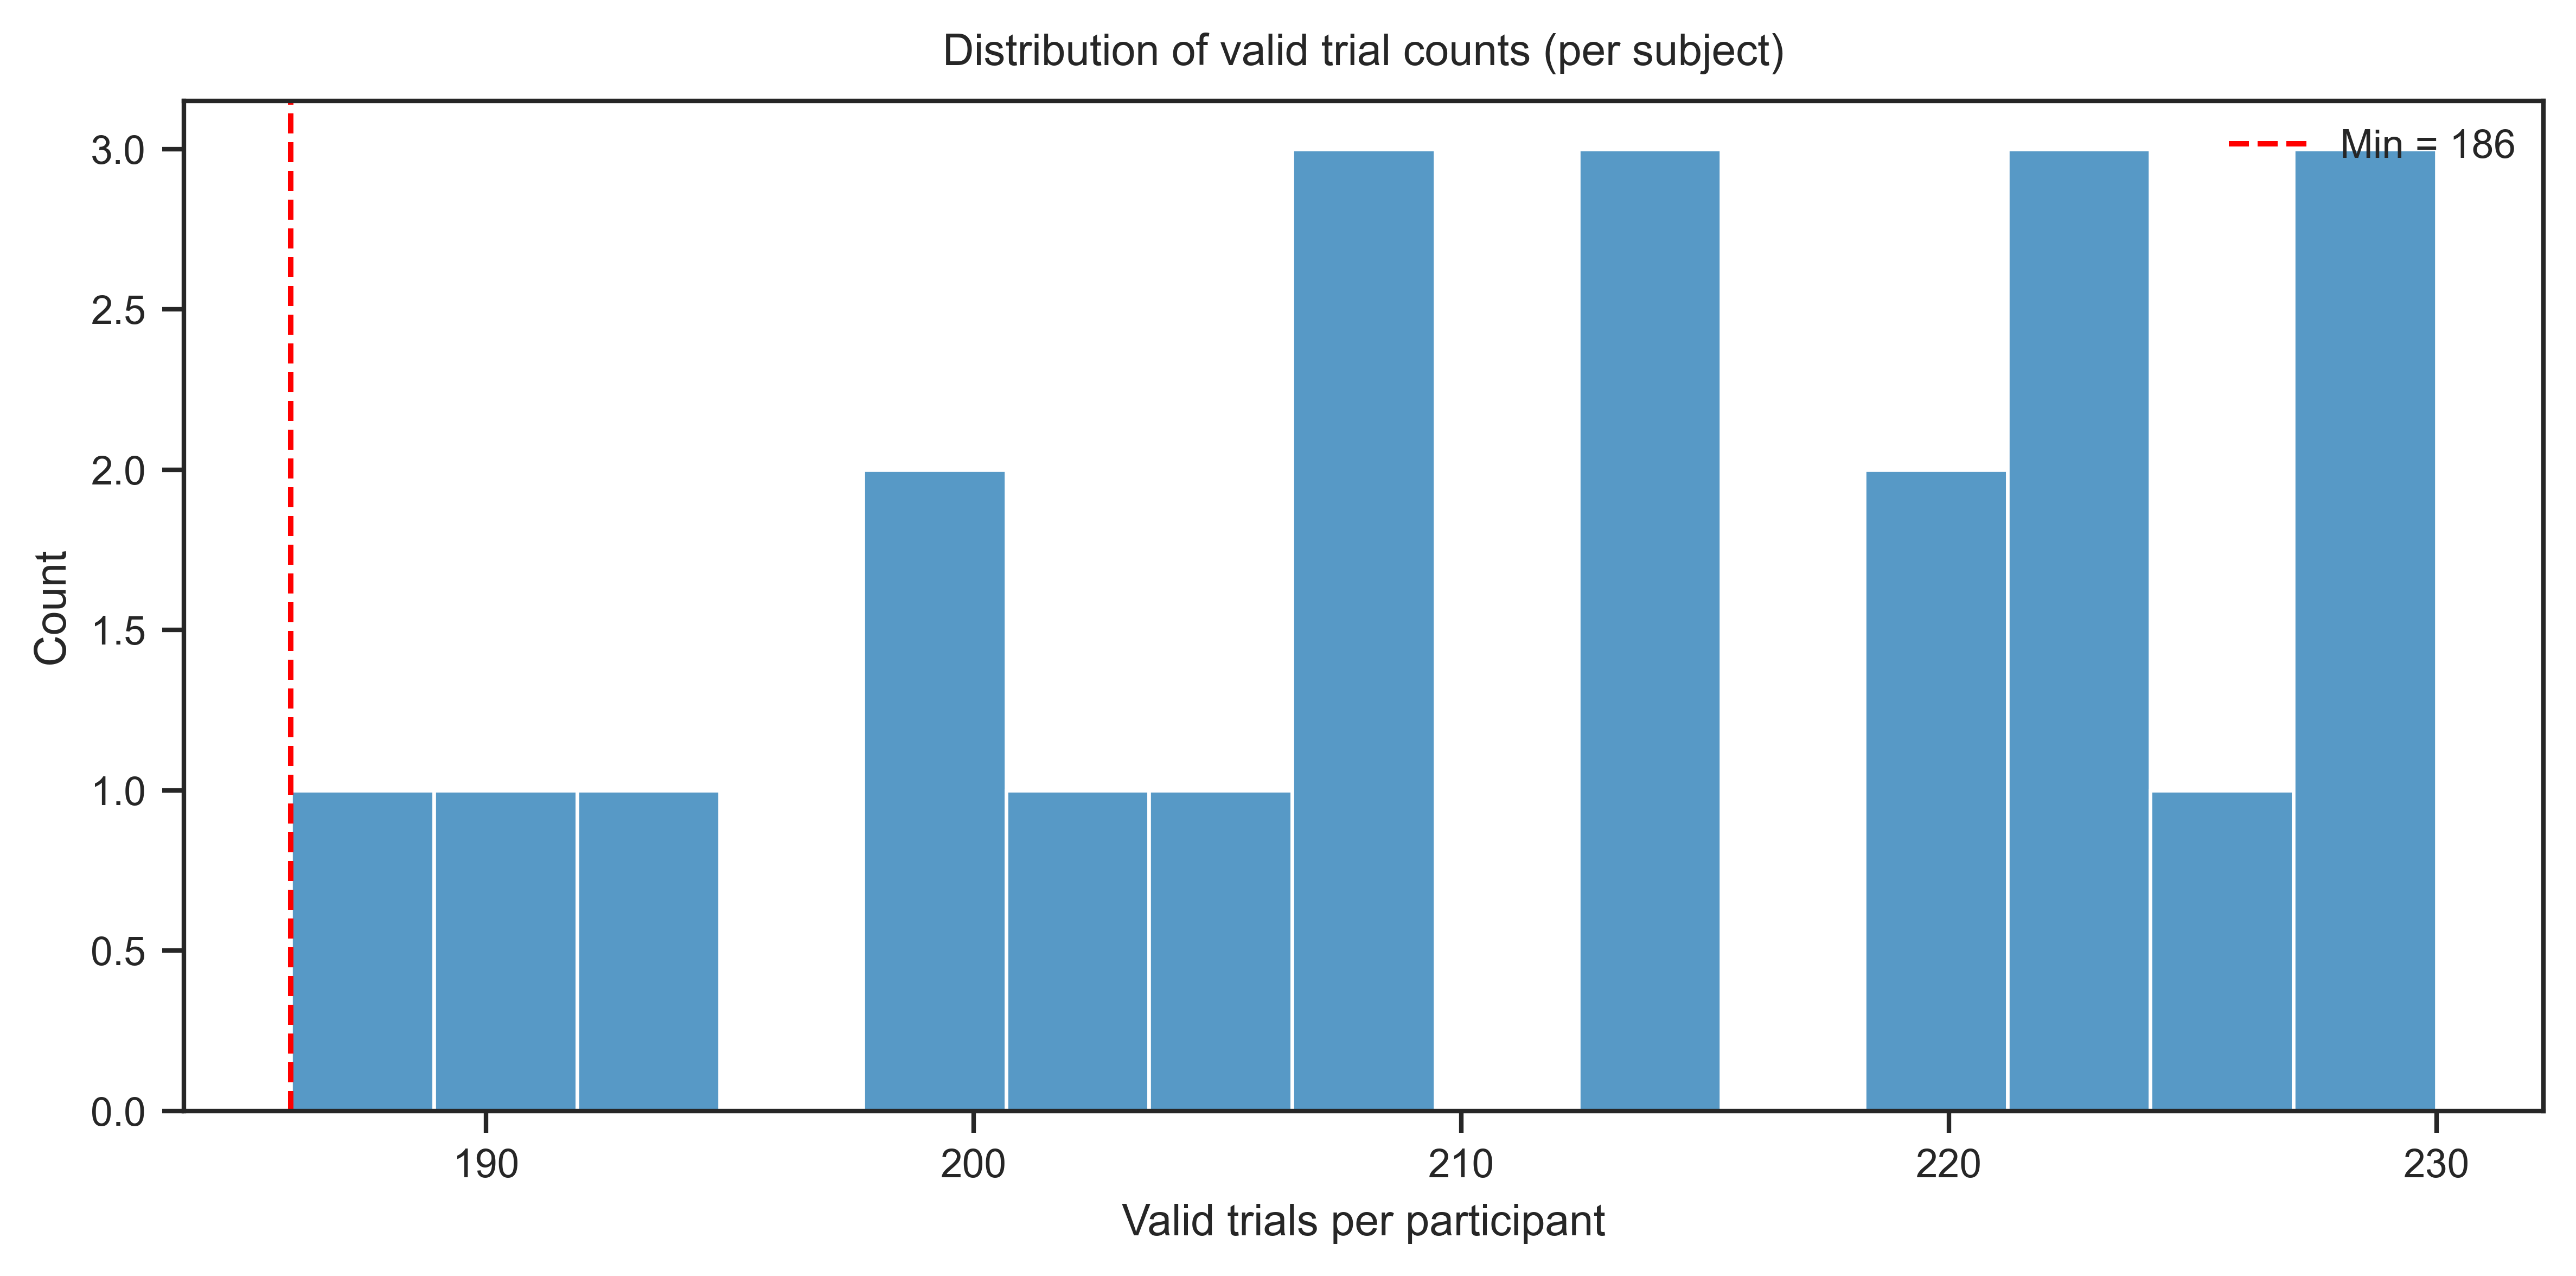

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[df['is_outlier'] == False]
trials_per_sub = df_clean.groupby('subID').size()
min_trials = trials_per_sub.min()
mean_trials = trials_per_sub.mean()
std_trials = trials_per_sub.std()
total_trials_before = len(df)
total_trials_after = len(df_clean)
retention_rate = total_trials_after / total_trials_before * 100

print(f"Total trials: {total_trials_before} -> {total_trials_after} ({retention_rate:.1f}% retained)")
print(f"Trials per subject: mean={mean_trials:.1f}, std={std_trials:.1f}, min={min_trials}")

low_trial_subjects = trials_per_sub[trials_per_sub < 180]
if not low_trial_subjects.empty:
    print(f"Warning: {len(low_trial_subjects)} subjects have < 180 trials")

plt.figure(figsize=(8, 4))
sns.histplot(trials_per_sub, bins=15, kde=False)
plt.axvline(min_trials, color='r', linestyle='--', label=f'Min = {min_trials}')
plt.xlabel("Valid trials per participant")
plt.ylabel("Count")
plt.title("Distribution of valid trial counts (per subject)")
plt.legend()
plt.tight_layout()
plt.show()

subject_trial_df = trials_per_sub.reset_index()
subject_trial_df.columns = ['subID', 'n_valid_trials']

#### Distribution checks
Histograms and Q-Q plots per subject.

In [13]:
#  Function  plotting histograms for each subject
def plot_histograms(df, column='keyDuration', groupby='subID', bins=30):
    subjects = df[groupby].unique()
    n_cols = 7
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column]
        axes[i].hist(sub_data.dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{column} Histogram - {sub}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    # Remove unused subplots
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)
    plt.tight_layout()
    plt.show()
#  Function  plotting Q-Q plots for each subject
def plot_qqplots(df, column='keyDuration', groupby='subID'):
    subjects = df[groupby].unique()
    n_cols = 7
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column].dropna()
        stats.probplot(sub_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot - {sub}')
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)
        plt.tight_layout()
    plt.show()


In [14]:
dfv = df[df["is_outlier"] == False].copy()

In [15]:
plot_histograms(dfv, column='rpr', groupby='subID')
plot_qqplots(dfv, column='rpr', groupby='subID')

#### Transition type distribution
Check balance of HH, HL, LH, LL conditions.

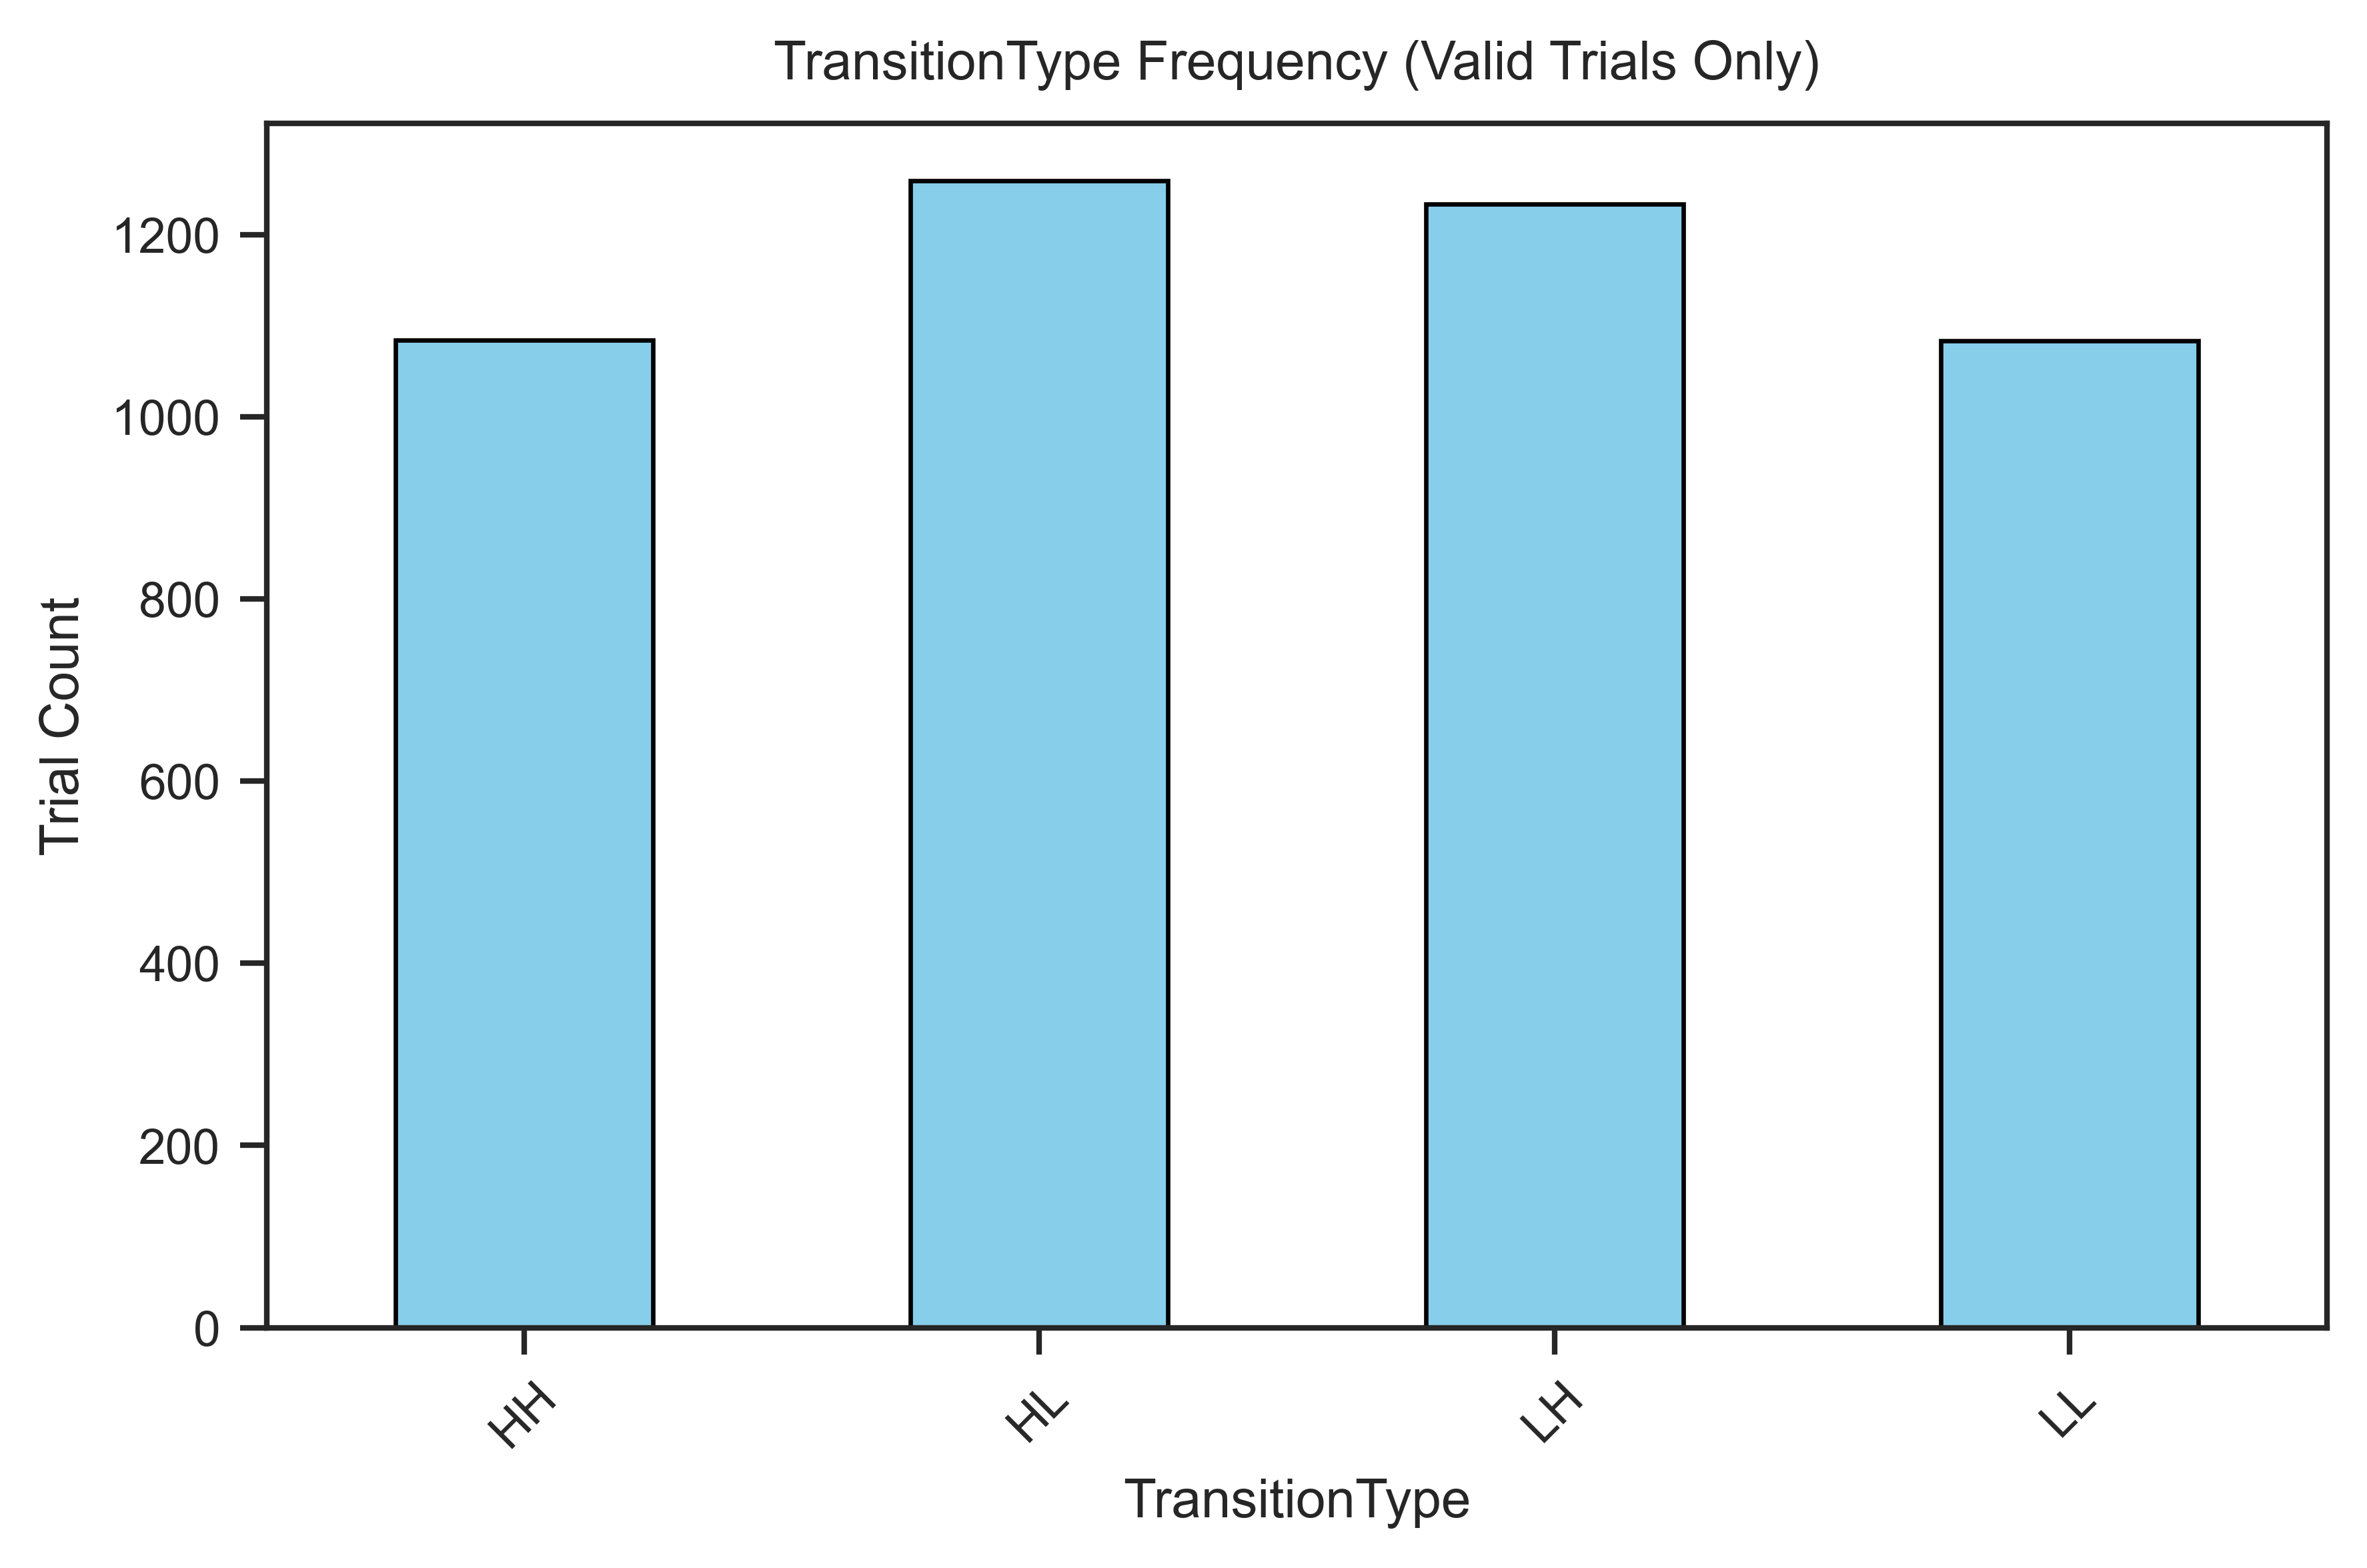

In [16]:
transition_counts = dfv["TransitionType"].value_counts().sort_index()
transition_prop = dfv["TransitionType"].value_counts(normalize=True).sort_index()
transition_counts.plot.bar(color='skyblue', edgecolor='black', figsize=(6, 4))
plt.title("TransitionType Frequency (Valid Trials Only)")
plt.xlabel("TransitionType")
plt.ylabel("Trial Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Check transition type balance per subject

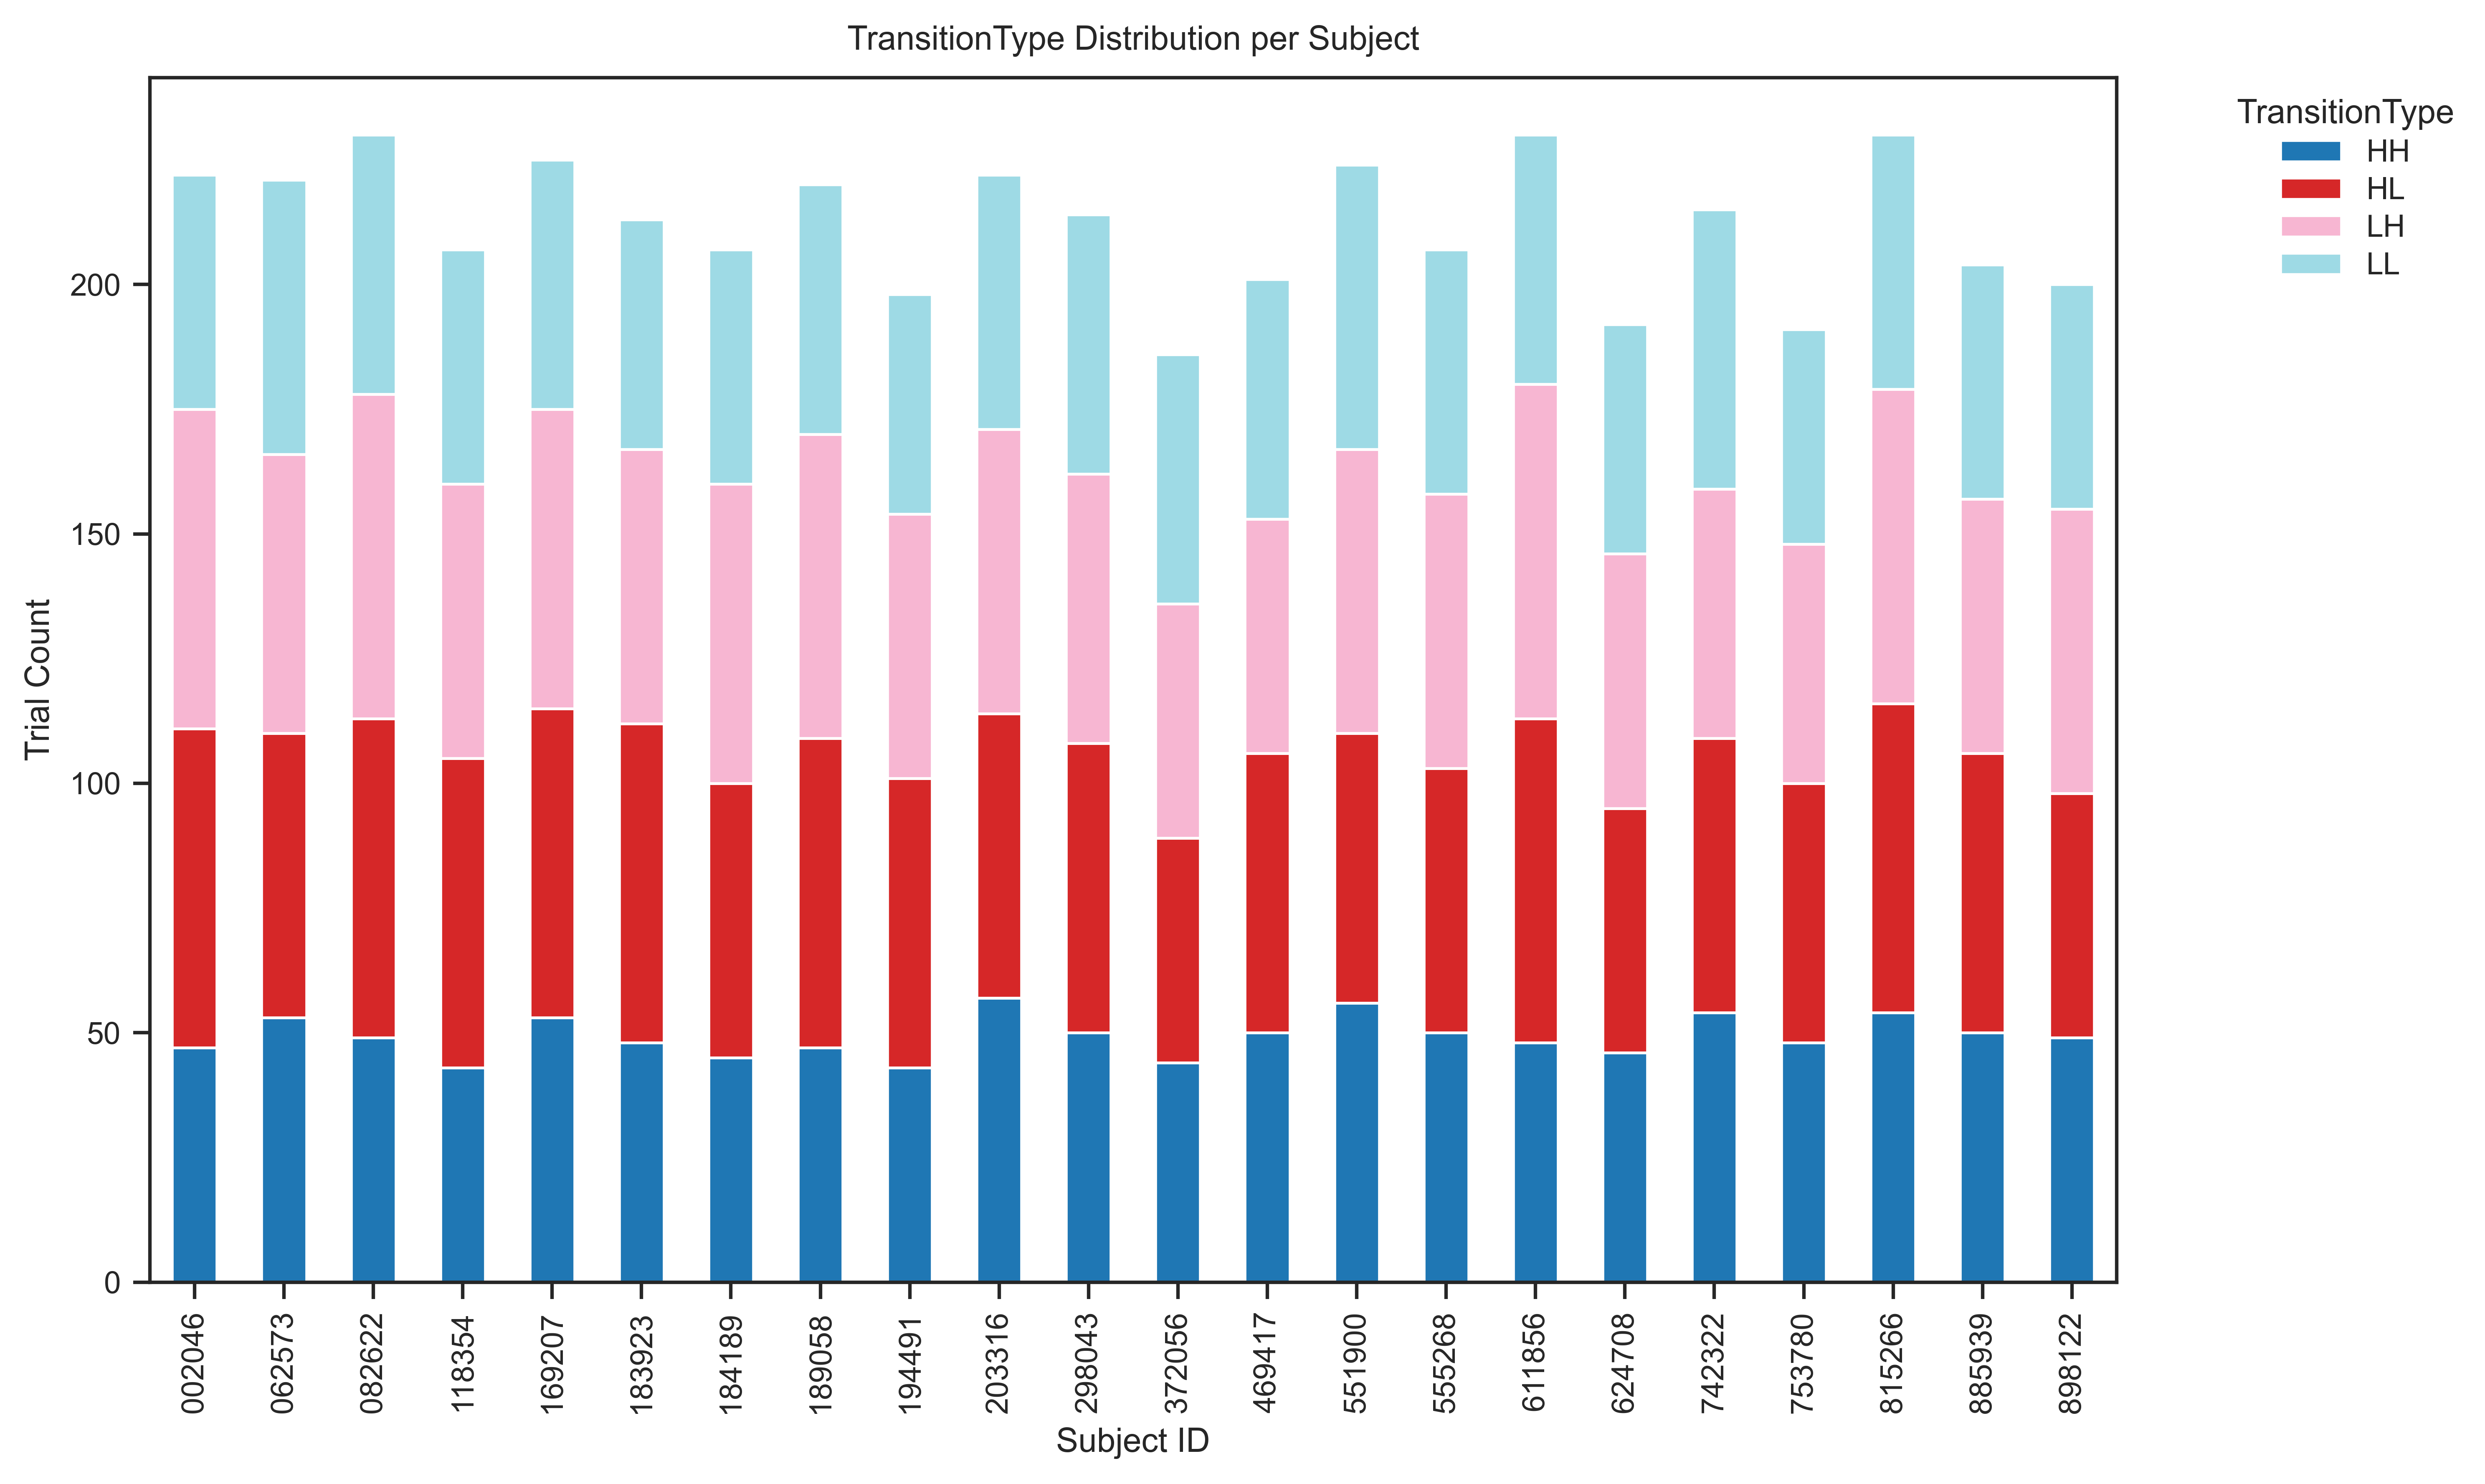

In [17]:
# Trial count per subject × condition
transition_counts = dfv.pivot_table(
    index="subID",
    columns="TransitionType",
    aggfunc="size",
    fill_value=0
)
# Add total trial count per subject
transition_counts["Total"] = transition_counts.sum(axis=1)
# Print trial count table
# Plot stacked bar chart
transition_counts.drop(columns="Total").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)
plt.title("TransitionType Distribution per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Trial Count")
plt.xticks(rotation=90)
plt.legend(title="TransitionType", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
# Compute and print percentage per condition
transition_props = transition_counts.drop(columns="Total").div(transition_counts["Total"], axis=0)


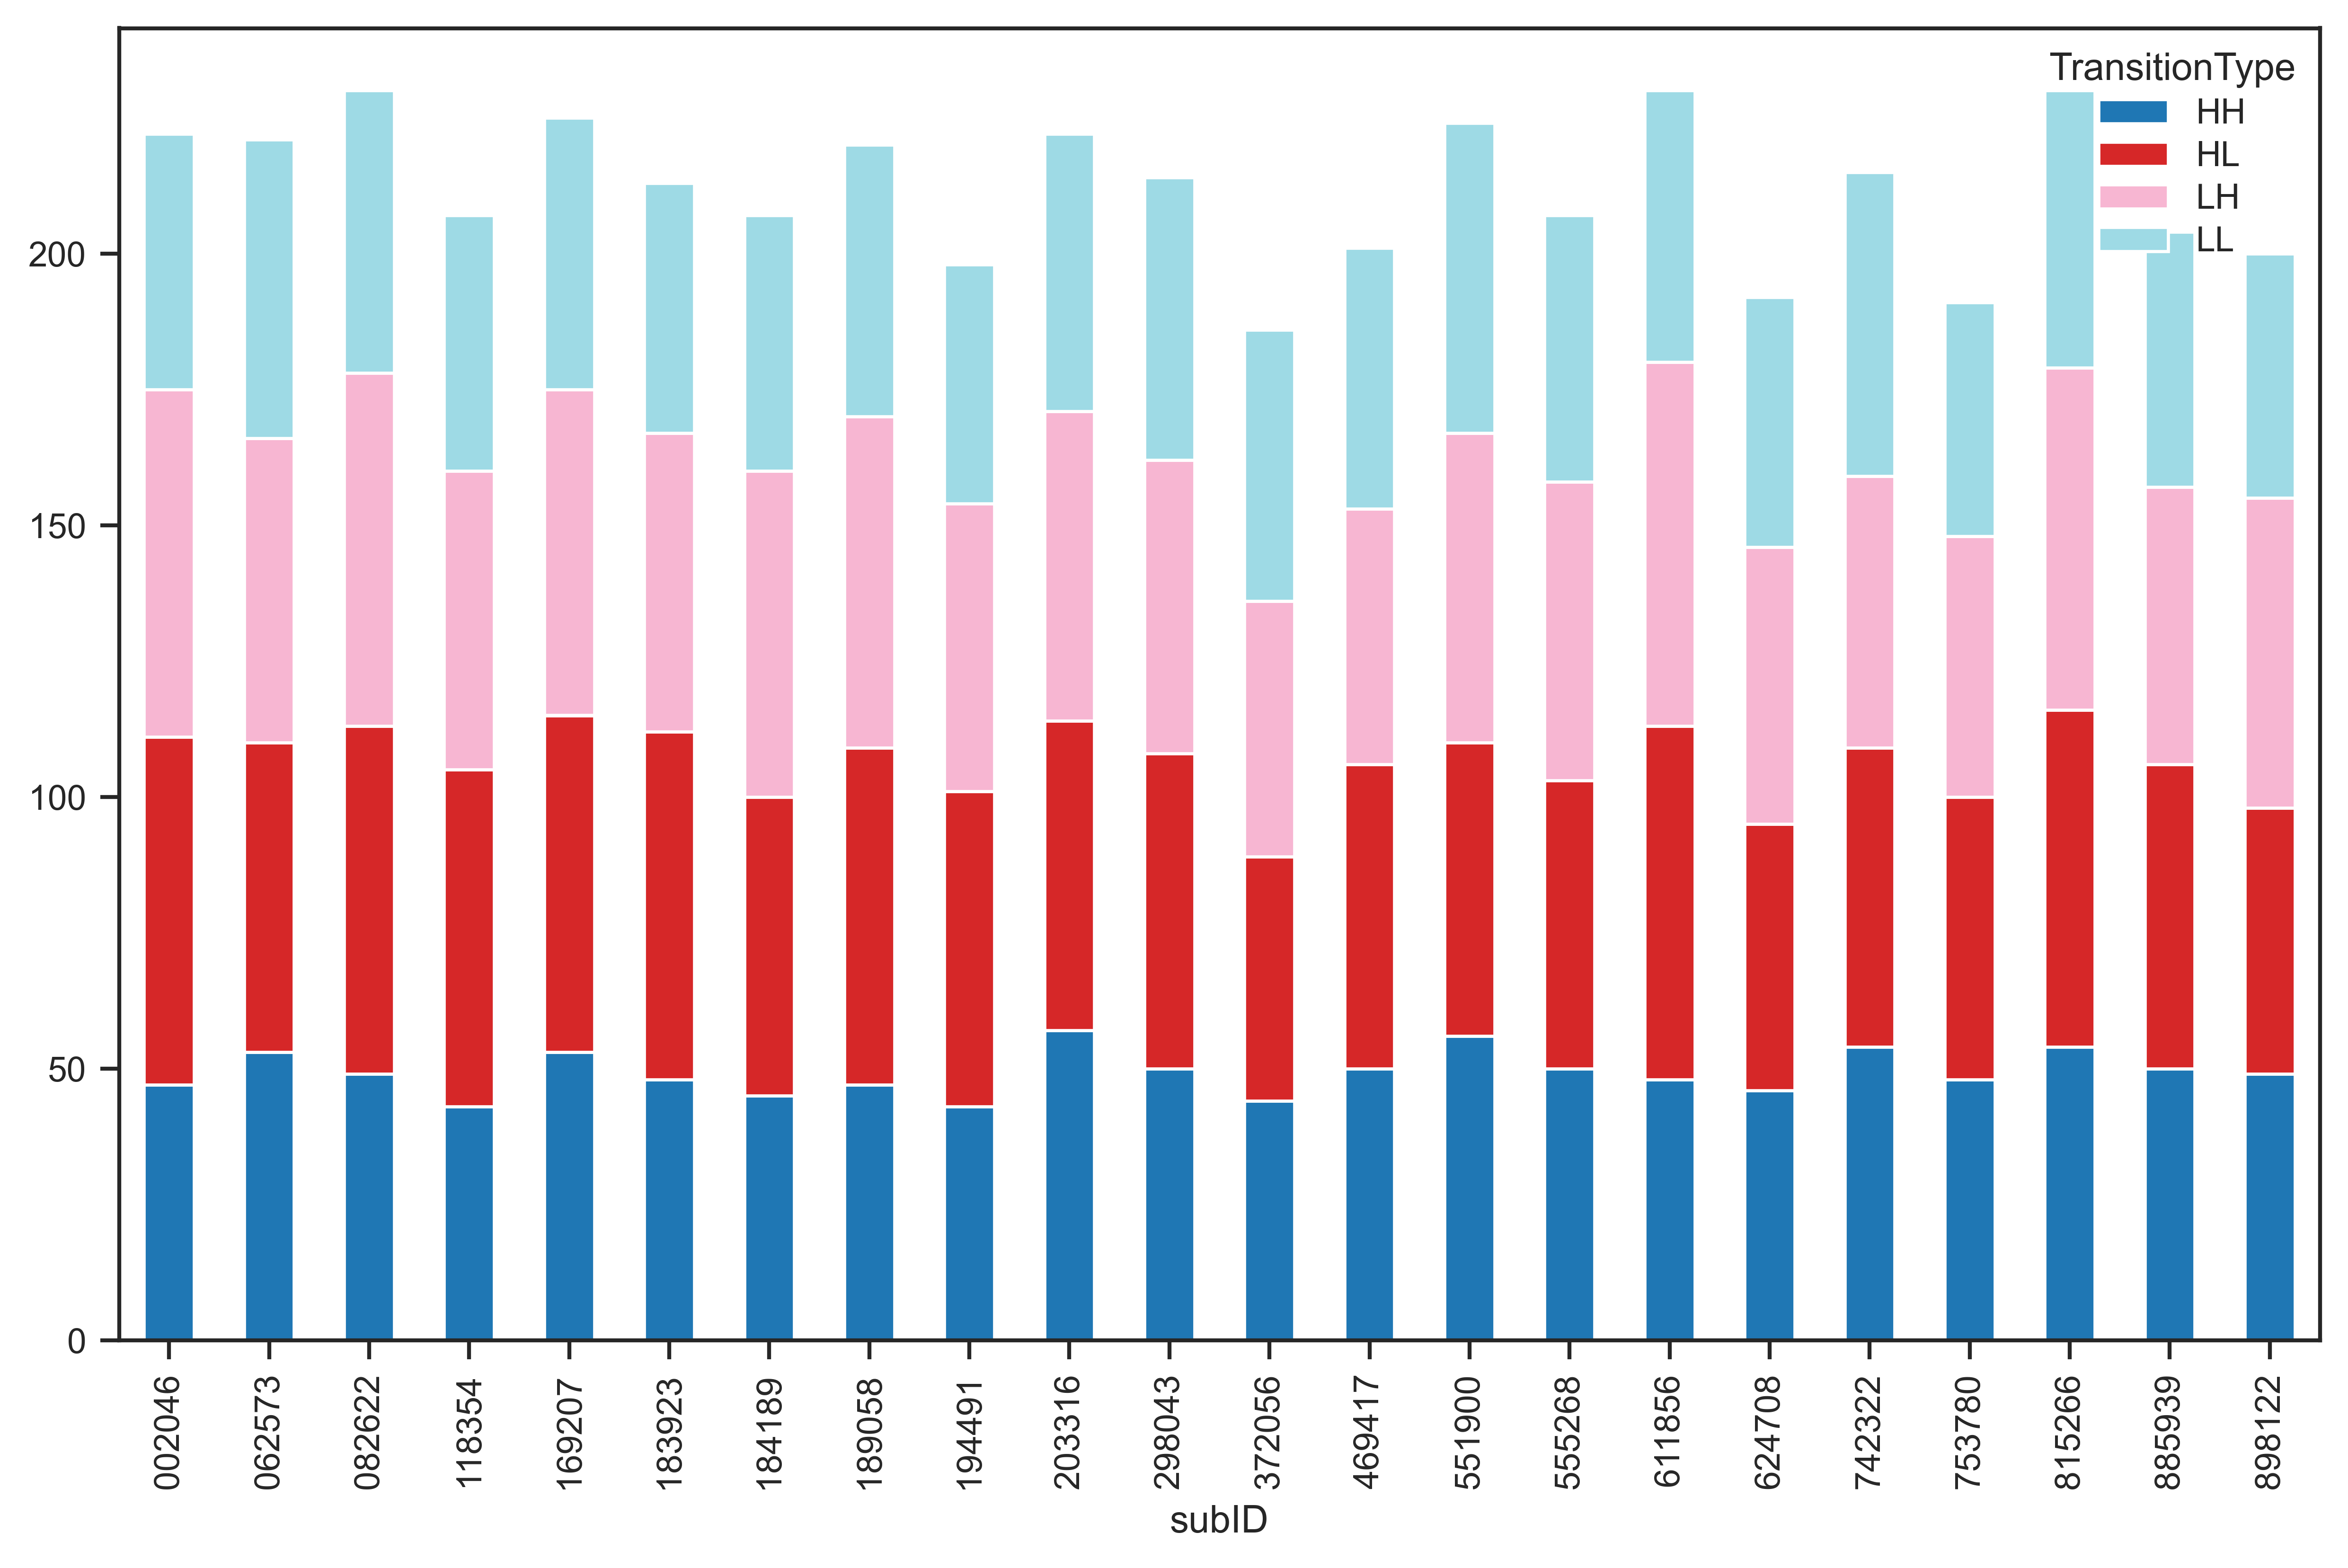

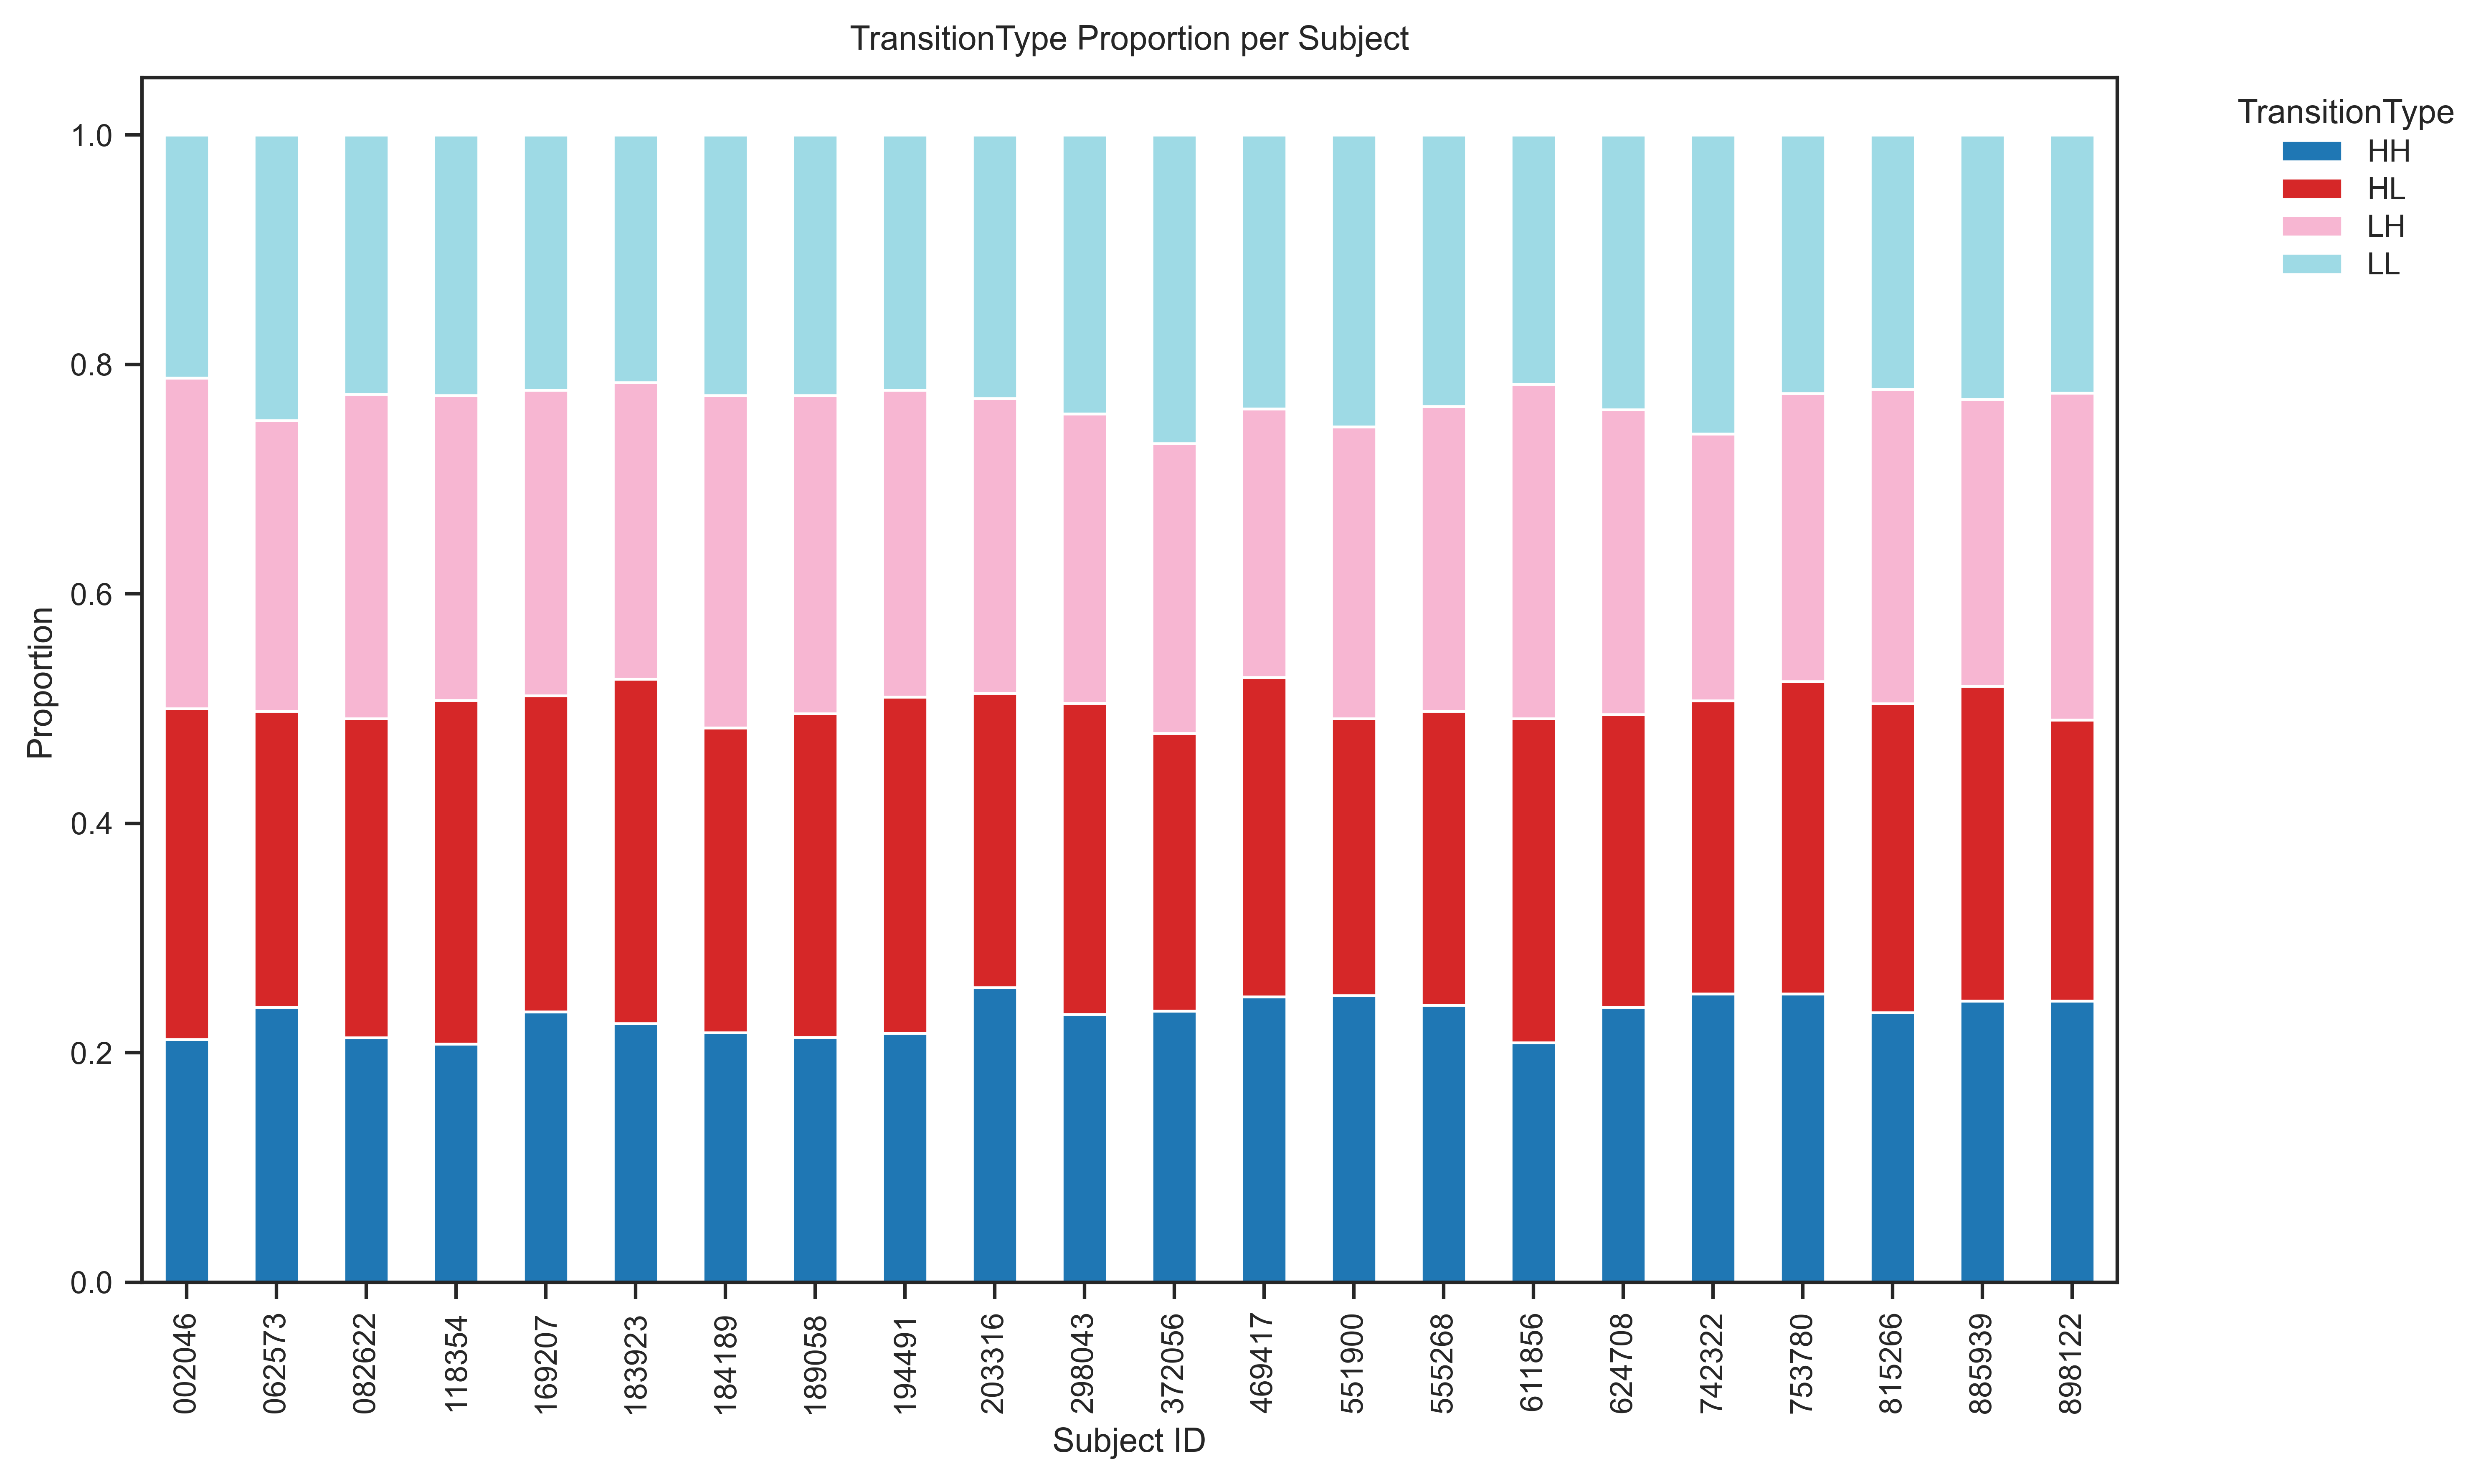

In [18]:
# subID × TransitionType 
transition_by_subject = dfv.pivot_table( index="subID", columns="TransitionType", aggfunc="size", fill_value=0)
transition_by_subject.plot( kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
transition_prop = transition_by_subject.div(transition_by_subject.sum(axis=1), axis=0)
transition_prop.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("TransitionType Proportion per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.legend(title="TransitionType", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Response variability by coherence level
Compare SD of reproduced durations between high/low coherence conditions.

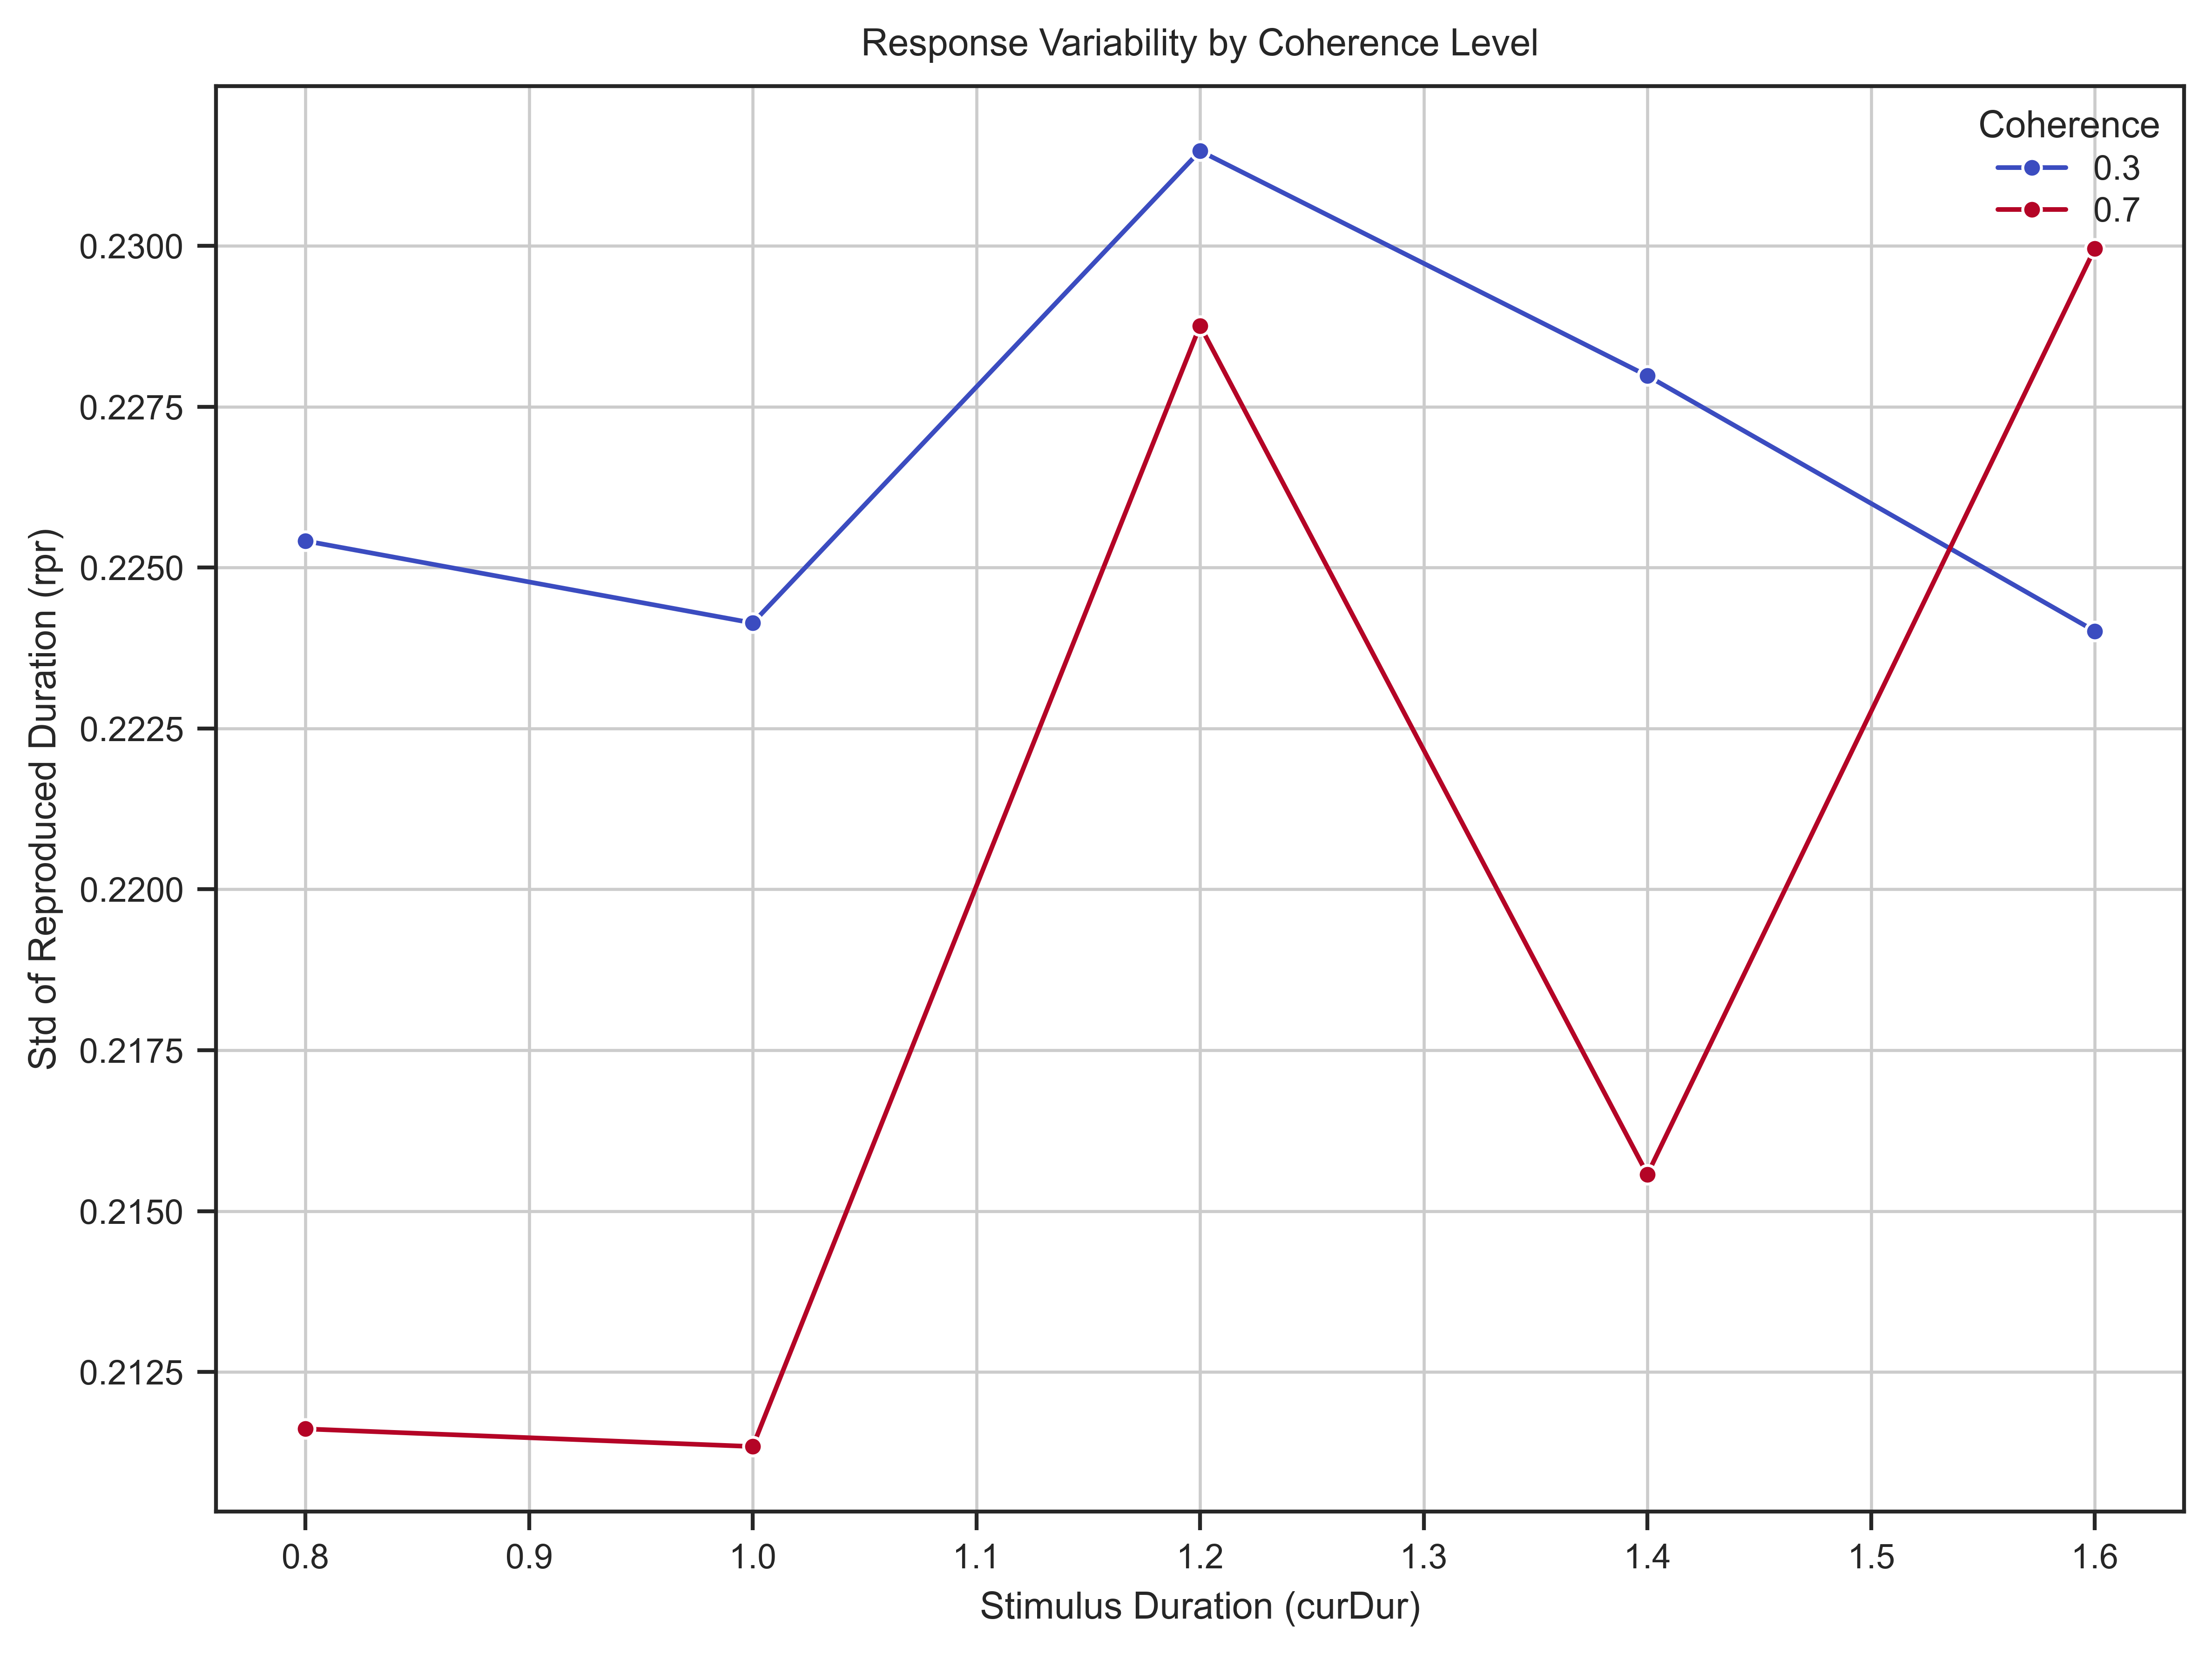

In [19]:
# Group by duration and coherence, then compute SD of reproduction
df_sd = (
    dfv.groupby(["curDur", "curCoherence"])["rpr"]
    .std()
    .reset_index()
    .rename(columns={"rpr": "std_rpr"})
)
# Plot
plt.figure(figsize=(8, 6))
sns.lineplot(data=df_sd, x="curDur", y="std_rpr", hue="curCoherence", marker="o", palette="coolwarm")
plt.title("Response Variability by Coherence Level")
plt.xlabel("Stimulus Duration (curDur)")
plt.ylabel("Std of Reproduced Duration (rpr)")
plt.legend(title="Coherence")
plt.grid(True)
plt.tight_layout()
plt.show()
from scipy.stats import ttest_ind
for dur in dfv['curDur'].unique():
    sub = dfv[dfv['curDur'] == dur]
    std_03 = sub[sub['curCoherence'] == 0.3]['rpr']
    std_07 = sub[sub['curCoherence'] == 0.7]['rpr']
    t, p = ttest_ind(std_03, std_07, equal_var=False)


#### Conclusion
The coherence/uncertainty manipulation is **effective** (t-test significant at each duration level).

In [20]:
df['preDur1backc'] = df['preDur1back']-1.2
df['curDurc'] = df['curDur']-1.2
df['mean_rpr'] = df.groupby('subID')['rpr'].transform('mean')
df['resp_type'] = np.where(df['rpr'] > df['mean_rpr'], 'Long', 'Short')
df['preResp'] = df.groupby('subID')['resp_type'].shift(1)

In [21]:
df.is_outlier.value_counts()

is_outlier
False    4659
True      445
Name: count, dtype: int64

In [22]:
df.to_pickle("E1.pkl")
print(f"Saved to E1.pkl")

Saved to E1.pkl
